# Fine-tune and Deploy YOLO26-OBB on AMD Radeon Cloud

In this hands-on workshop, we use **Ultralytics YOLO26** on one **AMD Radeon PRO W7900D** to build an end-to-end oriented object detection workflow:

**COCO HBB weights → Sheep OBB fine-tuning → separate val/test evaluation → ONNX export → MIGraphX acceleration → real-time OBB tracking**

By the end, you will know how the same Ultralytics workflow connects training and deployment on AMD Radeon Cloud.

## Hands-on roadmap

1. Check the Ultralytics and AMD GPU environment.
2. Inspect the prepared AUTH-Sheep and SheepCounter OBB data.
3. Transfer a COCO HBB checkpoint into a one-class OBB model and fine-tune it on one GPU.
4. Validate on SheepCounter and held-out videos, then visualize the downstream adaptation.
5. Export to ONNX, verify MIGraphX, and benchmark steady-state inference.
6. Deploy YOLO26n-OBB + ByteTrack as a 30 FPS live video stream.

The prepared dataset, fallback checkpoint, and container keep the workflow reproducible and leave time for questions and exploration.

## 1. Check the environment

Confirm that Ultralytics loads correctly and the AMD GPU is available.

### Verify workshop storage

The image configures Ultralytics to load datasets from `/datasets` and model weights from `/models`. The next cell verifies those asset paths; Ultralytics keeps its relative `runs` directory under the notebook working directory.


In [ ]:
from pathlib import Path

from ultralytics import settings

NOTEBOOK_NAME = "Ultralytics_YOLO26_Sheep_OBB_AMD_Radeon_Cloud_Workshop.ipynb"
WORKSHOP = Path.cwd().resolve()
if not (WORKSHOP / NOTEBOOK_NAME).is_file():
    raise RuntimeError(
        f"Jupyter kernel working directory {WORKSHOP} is not the notebook directory. "
        "Open the notebook from its workshop checkout before running it."
    )

DATASETS_DIR = Path(settings["datasets_dir"])
WEIGHTS_DIR = Path(settings["weights_dir"])
RUNS_DIR = Path(settings["runs_dir"])

expected = {"datasets_dir": Path("/datasets"), "weights_dir": Path("/models")}
actual = {"datasets_dir": DATASETS_DIR, "weights_dir": WEIGHTS_DIR}
if actual != expected:
    raise RuntimeError(f"Unexpected image settings: {actual}; expected: {expected}")

for path in expected.values():
    if not path.is_dir():
        raise FileNotFoundError(f"Required image asset directory is missing: {path}")

print(f"datasets_dir: {DATASETS_DIR}")
print(f"weights_dir:  {WEIGHTS_DIR}")
print(f"runs_dir:     {RUNS_DIR} -> {(WORKSHOP / RUNS_DIR).resolve()}")


In [ ]:
import ultralytics

ultralytics.checks()

!rocm-smi --showuse --showmeminfo vram


## 2. Build the Sheep OBB dataset

We combine two public aerial datasets and keep the split easy to understand:

| Dataset | Original data | Workshop split |
|---|---|---|
| [SheepCounter v11](https://universe.roboflow.com/riisprivate/sheepcounter/dataset/11) | 1,220 train + 507 valid images | 1,220 train; 507 validation |
| [AUTH-Sheep](https://github.com/idmt-odoll/AUTH-Sheep) | 4 annotated UAV videos | `video1` + `video4`: 198 train; `video2` + `video3`: 154 test frames |

All four AUTH-Sheep videos are sampled every 15 frames. The result is **1,418 training images**, **507 validation images**, and **154 test frames**. For this workshop, we keep only the `sheep` annotations, as reflected in the dataset YAML below.

The YAML file below defines the dataset root, splits, and class name. Its label files use Ultralytics OBB format: `class x1 y1 x2 y2 x3 y3 x4 y4`, with four normalized corner points.


In [20]:
from pathlib import Path

DATASET = DATASETS_DIR / "sheep-datasets"
DATA_YAML = WORKSHOP / "config/sheep.yaml"

print(f"Dataset YAML: {DATA_YAML}\n")
print(DATA_YAML.read_text())


Dataset YAML: /workspace/ultralytics_workshop_20260913/sheep.yaml

train: sheep-datasets/images/train
val: sheep-datasets/images/sheepcounter_valid
test: sheep-datasets/images/test

names:
  0: sheep



### Preview the training data

The next cell shows one labeled frame from each AUTH-Sheep video used for training. It converts the normalized OBB corner coordinates to pixels and draws the oriented boxes on both images.


In [ ]:
from utils.workshop_utils import show_obb_train_samples

show_obb_train_samples(DATASET, ["auth_v1_00330.jpg", "auth_v4_01200.jpg"])


## 3. Transfer COCO HBB features to Sheep OBB

The source checkpoint is `yolo26n.pt`: an 80-class COCO horizontal-box detector. The target architecture is `yolo26n-obb.yaml`: a one-class oriented detector. Ultralytics transfers all shape-compatible features; the task-specific classification and angle components adapt during fine-tuning.

This deliberately demonstrates a real downstream change: **general HBB detection → aerial single-class OBB detection**.

### Preview the pretrained COCO model

The next cell runs the original COCO HBB checkpoint on one COCO validation image and one AUTH-Sheep aerial sample. Predictions are limited to the `sheep` class, making the change from a familiar COCO scene to the new aerial domain easy to see.


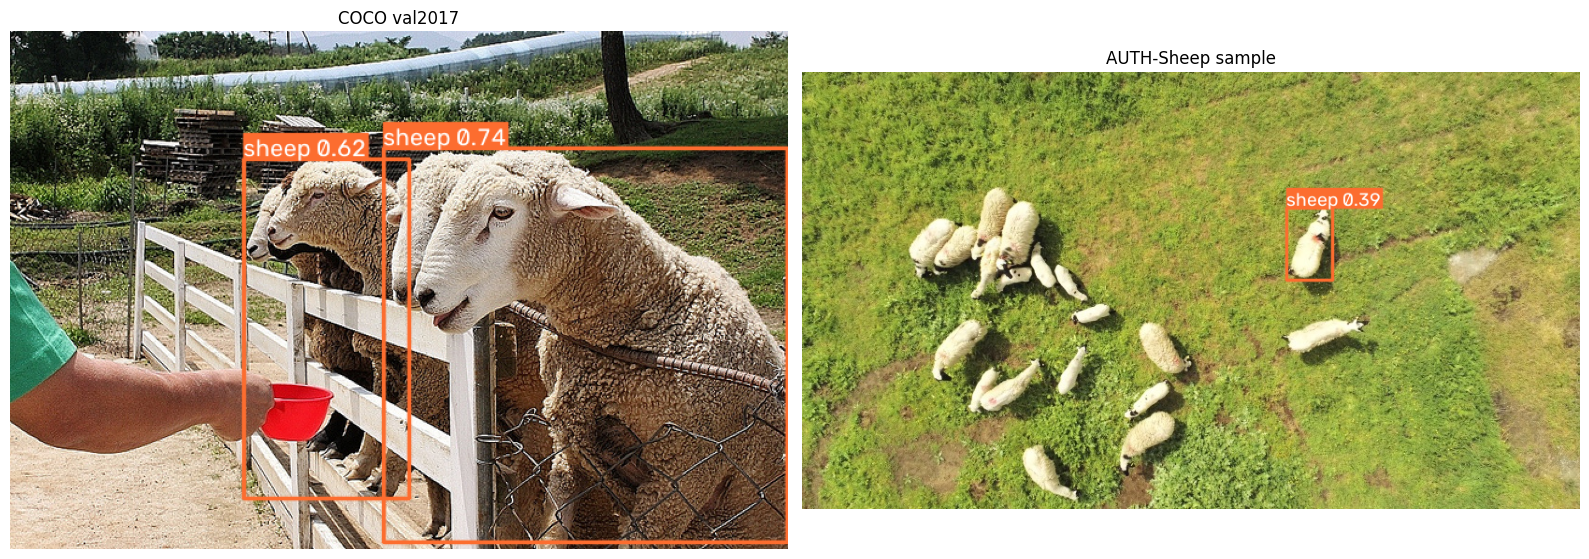

In [3]:
from ultralytics import YOLO
from utils.workshop_utils import show_predictions

WEIGHTS = WEIGHTS_DIR
coco_model = YOLO(WEIGHTS / "yolo26n.pt")

pretrain_images = [
    DATASETS_DIR / "coco-sheep-samples/coco_val2017_000000459437.jpg",
    DATASET / "images/train/auth_v1_00330.jpg",
]
pretrain_results = coco_model.predict(
    pretrain_images, classes=[18], conf=0.25, device=0, verbose=False
)

show_predictions(pretrain_results, ["COCO val2017", "AUTH-Sheep sample"])


In [4]:
model = YOLO("yolo26n-obb.yaml").load(WEIGHTS / "yolo26n.pt")


Transferred 708/792 items from pretrained weights


## 4. Fine-tune on one W7900D

The three workshop knobs stay visible in `model.train()`: training duration, input size, and batch size. Advanced optimizer and runtime defaults live in `train_defaults.yaml` and are expanded with `**train_defaults`.

On one W7900D, the reference 12-epoch run completed in **289.5 seconds**. Set `run_training = False` only when live training cannot start; the notebook will then load the prepared COCO-initialized checkpoint.


In [5]:
import time
from ultralytics.utils import YAML

artifacts = WEIGHTS_DIR
train_defaults = YAML.load(WORKSHOP / "config/train_defaults.yaml")
run_training = False

if run_training:
    started = time.perf_counter()
    results = model.train(
        data=DATA_YAML,
        epochs=12,
        imgsz=832,
        batch=64,
        **train_defaults,
    )
    best_weights = Path(results.save_dir) / "weights/best.pt"
    print(f"Training wall time: {time.perf_counter() - started:.1f} seconds")
else:
    best_weights = artifacts / "yolo26n_obb_sheep_coco_init.pt"


Fine-tuned model: /workspace/artifacts/final_models/yolo26n_obb_sheep_coco_init.pt


## 5. Evaluate the fine-tuned Sheep OBB model

### Quantitative evaluation

The `val` split contains 507 SheepCounter images. The `test` split contains 154 frames sampled every 15 frames from AUTH-Sheep `video2` and `video3`; neither video contributes any frame to training. We evaluate the two sources separately so their results remain easy to interpret.


In [6]:
import pandas as pd

tuned = YOLO(best_weights)
print("Fine-tuned model:", best_weights)

evaluation = []
for split, dataset_name, image_count in (
    ("val", "SheepCounter", 507),
    ("test", "AUTH-Sheep video2 + video3", 154),
):
    metrics = tuned.val(
        data=DATA_YAML,
        split=split,
        imgsz=832,
        batch=64,
        plots=False,
        verbose=False,
    )
    evaluation.append({
        "Split": split,
        "Dataset": dataset_name,
        "Images": image_count,
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
    })

display(pd.DataFrame(evaluation).round(3))


,Split,Dataset,Images,Precision,Recall,mAP50,mAP50-95
0,val,SheepCounter,507,0.870,0.850,0.932,0.662
1,test,AUTH-Sheep video2 + video3,154,0.671,0.788,0.761,0.394


### Qualitative before and after fine-tuning

COCO already contains the semantic class *sheep*, but its checkpoint was trained for natural-image HBB detection. The same held-out aerial frame makes the domain and task adaptation visible. This is a qualitative comparison—not a shared mAP evaluation—because HBB and OBB are different output tasks.


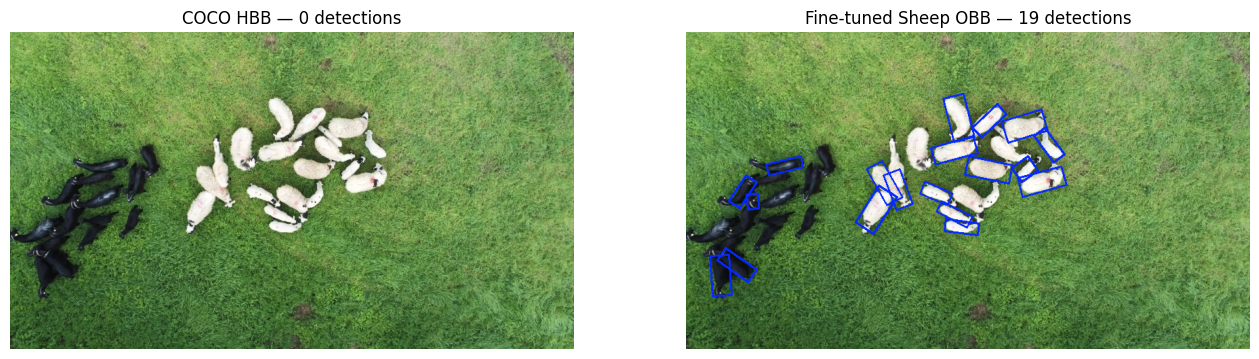

In [7]:
SAMPLE_IMAGE = DATASET / "images/test/auth_v3_00030.jpg"
coco_hbb = YOLO(WEIGHTS / "yolo26n.pt")
sheep_id = next(i for i, name in coco_hbb.names.items() if name == "sheep")

before = coco_hbb.predict(SAMPLE_IMAGE, classes=[sheep_id], conf=0.5, device=0, verbose=False)[0]
after = tuned.predict(SAMPLE_IMAGE, conf=0.5, device=0, verbose=False)[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
views = (
    (before, f"COCO HBB — {len(before.boxes)} detections"),
    (after, f"Fine-tuned Sheep OBB — {len(after.obb)} detections"),
)
for axis, (result, title) in zip(axes, views):
    axis.imshow(cv2.cvtColor(result.plot(labels=False, conf=False, line_width=2), cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")
plt.show()

## 6. Export the fine-tuned OBB model to ONNX

Export the raw OBB network at a deployment resolution of 640×640. Ultralytics keeps rotated-box decoding and NMS outside the ONNX graph, avoiding task-specific Top-K and rotated post-processing operators in the graph.

In [8]:
DEPLOY_SIZE = 640

export_model = YOLO(best_weights)
export_model.model.model[-1].end2end = False
ONNX_MODEL = Path(export_model.export(
    format="onnx",
    imgsz=DEPLOY_SIZE,
    opset=20,
    simplify=False,
    device=0,
))
print("Exported model:", ONNX_MODEL)

Ultralytics 8.4.75 🚀 Python-3.10.12 torch-2.9.1+gitff65f5b CUDA:0 (AMD Radeon PRO W7900D, 49136MiB)
YOLO26n-obb summary (fused): 165 layers, 2,637,836 parameters, 0 gradients

PyTorch: starting from '/workspace/artifacts/final_models/yolo26n_obb_sheep_coco_init.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.5 MB)

ONNX: starting export with onnx 1.19.1 opset 20...
ONNX: export success ✅ 0.5s, saved as '/workspace/artifacts/final_models/yolo26n_obb_sheep_coco_init.onnx' (9.5 MB)

Export complete (0.8s)
Results saved to /workspace/artifacts/final_models/yolo26n_obb_sheep_coco_init.onnx
Predict:         yolo predict task=obb model=/workspace/artifacts/final_models/yolo26n_obb_sheep_coco_init.onnx imgsz=640 
Validate:        yolo val task=obb model=/workspace/artifacts/final_models/yolo26n_obb_sheep_coco_init.onnx imgsz=640 data=/workspace/ultralytics_workshop_20260913/sheep.yaml  
Visualize:       https://netron.app
Exported model: /workspace/artifacts/fina

## 7. Run ONNX with MIGraphX through Ultralytics

The neural network runs through `MIGraphXExecutionProvider`; Ultralytics still handles image preprocessing, OBB decoding, rotated NMS, and result visualization. The prepared branch exposes the selected provider through the Ultralytics backend.

In [9]:
import onnxruntime as ort

from ultralytics.models.yolo.obb.predict import OBBPredictor

assert "MIGraphXExecutionProvider" in ort.get_available_providers()

migraphx_predictor = OBBPredictor(overrides={
    "model": str(ONNX_MODEL),
    "task": "obb",
    "device": 0,
    "imgsz": DEPLOY_SIZE,
    "batch": 1,
    "conf": CONFIDENCE,
    "save": False,
    "verbose": False,
})
migraphx_predictor.setup_model(model=str(ONNX_MODEL), verbose=False)
migraphx_predictor.done_warmup = True

migraphx_result = migraphx_predictor(source=str(SAMPLE_IMAGE))[0]
backend = migraphx_predictor.model.backend
provider = getattr(backend, "provider", None)

print("Ultralytics backend:", type(backend).__name__)
print("ONNX Runtime provider:", provider)
assert provider == "MIGraphXExecutionProvider"

Loading /workspace/artifacts/final_models/yolo26n_obb_sheep_coco_init.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


2026-09-05 08:50:40.498254905 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:
2026-09-05 08:50:40.579898698 [W:onnxruntime:Default, migraphx_execution_provider.cc:1262 compile_program] Model Compile: Begin
2026-09-05 08:50:59.397230027 [W:onnxruntime:Default, migraphx_execution_provider.cc:1267 compile_program] Model Compile: Complete


Ultralytics backend: ONNXBackend
ONNX Runtime provider: MIGraphXExecutionProvider


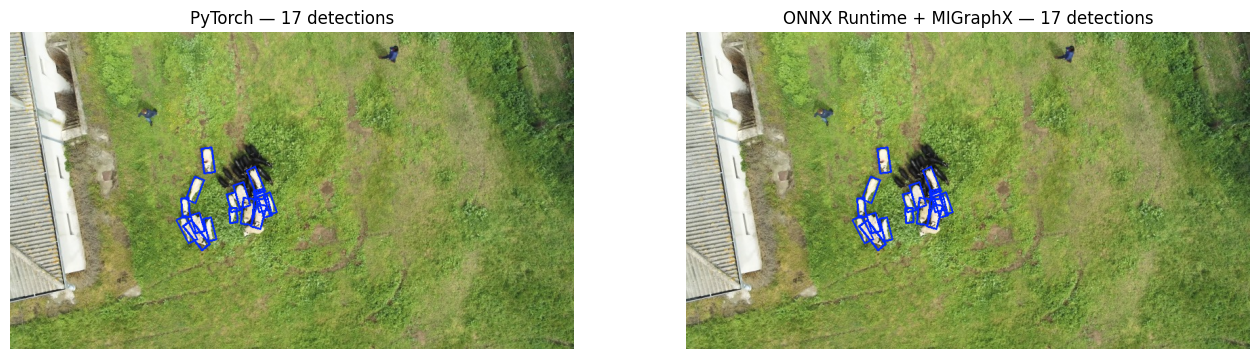

In [10]:
pytorch_export_path = YOLO(best_weights)
pytorch_export_path.model.model[-1].end2end = False
pytorch_predictor = OBBPredictor(overrides={
    "task": "obb", "device": 0, "imgsz": DEPLOY_SIZE,
    "batch": 1, "conf": CONFIDENCE, "save": False, "verbose": False,
})
pytorch_predictor.setup_model(model=pytorch_export_path.model, verbose=False)
pytorch_predictor.done_warmup = True
pytorch_result = pytorch_predictor(source=str(SAMPLE_IMAGE))[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for axis, result, title in zip(
    axes,
    (pytorch_result, migraphx_result),
    ("PyTorch", "ONNX Runtime + MIGraphX"),
):
    axis.imshow(cv2.cvtColor(result.plot(labels=False, conf=False, line_width=2), cv2.COLOR_BGR2RGB))
    axis.set_title(f"{title} — {len(result.obb)} detections")
    axis.axis("off")
plt.show()

## 8. Measure steady-state inference acceleration

This benchmark compares only the raw `(1, 3, 640, 640)` model forward pass. It excludes image loading, resize, OBB NMS, drawing, file I/O, and the one-time MIGraphX graph compilation.

Reference W7900D runs measured **PyTorch FP16 at 10.8–12.6 ms** and **MIGraphX FP16 at 2.05–2.08 ms**, or approximately **5.3–6.1× speedup**. Rerun the cell on your own Radeon Cloud instance.

YOLO26n-obb summary (fused): 165 layers, 2,637,836 parameters, 0 gradients


2026-09-05 08:51:00.522686782 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:
2026-09-05 08:51:00.623152151 [W:onnxruntime:Default, migraphx_execution_provider.cc:1245 calibrate_and_quantize] Quantizing input program to fp16
2026-09-05 08:51:04.411644626 [W:onnxruntime:Default, migraphx_execution_provider.cc:1247 calibrate_and_quantize] Quantizing fp16: Complete
2026-09-05 08:51:04.411666376 [W:onnxruntime:Default, migraphx_execution_provider.cc:1262 compile_program] Model Compile: Begin
2026-09-05 08:51:25.388073590 [W:onnxruntime:Default, migraphx_execution_provider.cc:1267 compile_program] Model Compile: Complete


,Backend,Precision,Latency (ms),FPS,Speedup vs PyTorch
0,PyTorch eager,FP16,7.416,134.841,1.000
1,ONNX Runtime + MIGraphX,FP16,1.389,719.696,5.337


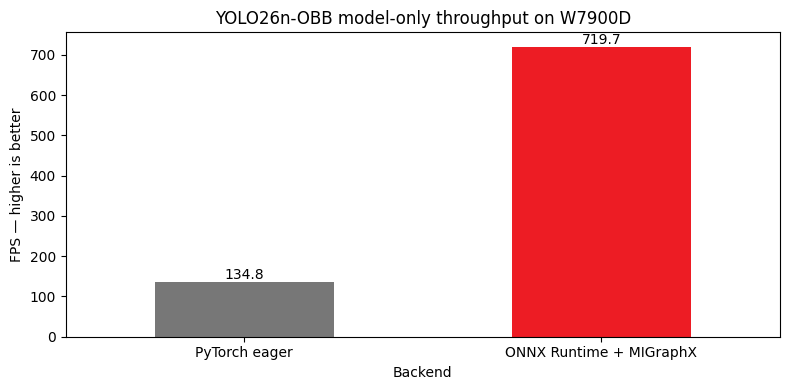

In [11]:
import torch

def mean_latency(run_once, warmup=3, runs=20):
    for _ in range(warmup):
        run_once()
    values = []
    for _ in range(runs):
        started = time.perf_counter()
        run_once()
        values.append((time.perf_counter() - started) * 1000)
    return float(np.mean(values))


shape = (1, 3, DEPLOY_SIZE, DEPLOY_SIZE)
torch_net = YOLO(best_weights).model.eval().to("cuda:0")
torch_net.model[-1].end2end = False
torch_net.fuse()
torch_net.model[-1].export = True
torch_net = torch_net.half()
torch_input = torch.rand(*shape, device="cuda:0").half()

def run_pytorch():
    with torch.inference_mode():
        torch_net(torch_input)
    torch.cuda.synchronize()

pytorch_ms = mean_latency(run_pytorch)

options = ort.SessionOptions()
options.log_severity_level = 3
options.add_session_config_entry("session.disable_cpu_ep_fallback", "1")
session = ort.InferenceSession(
    str(ONNX_MODEL),
    sess_options=options,
    providers=[("MIGraphXExecutionProvider", {
        "device_id": "0",
        "migraphx_fp16_enable": "1",
    })],
)
input_name = session.get_inputs()[0].name
output_names = [output.name for output in session.get_outputs()]
ort_input = np.random.random(shape).astype(np.float32)

def run_migraphx():
    session.run(output_names, {input_name: ort_input})

migraphx_ms = mean_latency(run_migraphx)
assert session.get_providers()[0] == "MIGraphXExecutionProvider"

speed = pd.DataFrame([
    {"Backend": "PyTorch eager", "Precision": "FP16", "Latency (ms)": pytorch_ms},
    {"Backend": "ONNX Runtime + MIGraphX", "Precision": "FP16", "Latency (ms)": migraphx_ms},
])
speed["FPS"] = 1000 / speed["Latency (ms)"]
speed["Speedup vs PyTorch"] = pytorch_ms / speed["Latency (ms)"]
display(speed.round(3))

ax = speed.plot.bar(x="Backend", y="FPS", legend=False, color=["#777777", "#ED1C24"], figsize=(8, 4))
ax.set_ylabel("FPS — higher is better")
ax.set_title("YOLO26n-OBB model-only throughput on W7900D")
ax.bar_label(ax.containers[0], fmt="%.1f")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Deploy a real-time OBB tracking stream

The Notebook opens the video with OpenCV and explicitly calls Ultralytics `model.track()` for every frame. `LiveCanvas` handles only OBB rendering, source-FPS pacing, and latest-frame delivery to the Jupyter Canvas.

Change `VIDEO_NAME` to switch between the two fully held-out videos. The selected video runs from beginning to end. Low-confidence detections are available only to ByteTrack association; the canvas renders confirmed tracks at confidence 0.25 or above.

In [ ]:
from utils.live_tracking_demo import LiveCanvas

VIDEO_NAME = "video2"  # Choose "video2" or "video3"
VIDEO_PATH = DATASET / "raw/AUTH-Sheep" / f"{VIDEO_NAME}.mp4"
TRACKER = WORKSHOP / "config/bytetrack_sheep_workshop.yaml"

video = cv2.VideoCapture(str(VIDEO_PATH))
source_fps = video.get(cv2.CAP_PROP_FPS) or 30.0
track_model = YOLO(best_weights)
canvas = LiveCanvas(fps=source_fps, size=(960, 540), display_conf=0.25)

while video.isOpened():
    success, frame = video.read()
    if not success:
        break

    frame = cv2.resize(frame, canvas.size)
    tracked = track_model.track(
        frame,
        persist=True,
        tracker=str(TRACKER),
        imgsz=832,
        conf=0.05,  # Low-confidence candidates for ByteTrack association
        half=True,
        device=0,
        verbose=False,
    )[0]
    canvas.write(tracked)

video.release()
canvas.finish()

## Wrap-up and free exploration

You have completed one continuous Ultralytics workflow on AMD Radeon Cloud:

- initialized an OBB task from general COCO HBB features;
- fine-tuned and validated on exactly one W7900D;
- exported the model to ONNX and verified MIGraphX execution;
- measured steady-state acceleration;
- deployed real-time oriented detection and ByteTrack tracking at the source frame rate.

Try switching `VIDEO_NAME`, or changing `CONFIDENCE`, `imgsz`, and the tracker thresholds. The key pattern remains the same: **Ultralytics connects data, training, validation, export, and deployment through a compact Python API.**